## Laptop Price Prediction by Linear regression

## Workflow Steps:

1. **Data Collection & Loading** – Gather and import the laptop dataset for analysis.

2. **Exploratory Data Analysis (EDA)** – Understand data patterns, relationships, and key insights through visualization and summary statistics.

3. **Data Cleaning & Preprocessing** – Handle missing values, outliers, and inconsistent data formats to ensure quality input.

4. **Feature Engineering & Selection** – Create new meaningful variables and select the most relevant features for the model.

5. **Train-Test Split** – Divide the dataset into training and testing subsets to validate model performance.

6. **Model Training** – Build and train a Linear Regression model on the training data.

7. **Model Testing** – Use the test data to make predictions and assess generalization capability.

8. **Model Evaluation** – Evaluate the model’s performance using metrics such as R², MAE, and RMSE.

9. **Model Deployment** – Deploy the final model for real-world use or integration into an application.

## Columns detail

1. **Brand**	Represents the laptop brand, with options including Dell, HP, Lenovo, Asus, and Acer.
2. **Processor_Speed**	Indicates the speed of the laptop's processor, generated uniformly between 1.5 and 4.0 GHz.
3. **RAM_Size**	Represents the random selection of RAM sizes, including 4GB, 8GB, 16GB, and 32GB.
4. **Storage_Capacity**	Simulates different storage capacities with options of 256GB, 512GB, and 1000GB (1TB).
5. **Screen_Size**	Represents the size of the laptop screen, randomly generated between 11 and 17 inches.
6. **Weight**	Indicates the weight of the laptop in kilograms, simulated uniformly between 2.0 and 5.0 kg.
7. **Price**	Simulates the laptop prices based on a linear relationship with the features, including some added noise to mimic


## Libraries Used

1. **NumPy & Pandas** – For efficient data handling, manipulation, and analysis.
2. **Matplotlib & Seaborn** – For data visualization and exploratory data analysis (EDA).
3. **Scikit-Learn (sklearn)** – For building, training, and evaluating the Linear Regression model.
4. **Streamlit & Pickle** – For model deployment and saving/loading the trained model.

In [80]:
## importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [81]:
## Loading the dataset
df = pd.read_csv("Laptop_price.csv")

In [82]:
df.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


In [83]:
df.shape ## data has 1000 records

(1000, 7)

In [84]:
df.info() 
'''Here Brand,RAM_Size,Storage_Capacity are categorical columns,
Processor_Speed,Screen_Size,Weight are numerical column(continuous) &
Price is the output column
'''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


'Here Brand,RAM_Size,Storage_Capacity are categorical columns,\nProcessor_Speed,Screen_Size,Weight are numerical column(continuous) &\nPrice is the output column\n'

In [85]:
df.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


In [86]:
## checking for null values
df.isna().sum() ## there are no null values

Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64

In [87]:
## checking for duplicate values
df.duplicated().sum() ## there are no duplicate records

np.int64(0)

In [88]:
df["Brand"].value_counts() ## There are 5 categories in Brand column

Brand
Dell      210
Asus      206
Acer      204
Lenovo    190
HP        190
Name: count, dtype: int64

In [89]:
## One hot encoding Brand column
df = pd.get_dummies(df,columns=["Brand"])

In [90]:
df[["Brand_Acer","Brand_Asus","Brand_Dell","Brand_HP","Brand_Lenovo"]]=\
df[["Brand_Acer","Brand_Asus","Brand_Dell","Brand_HP","Brand_Lenovo"]].astype("int")

In [91]:
df

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price,Brand_Acer,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo
0,3.830296,16,512,11.185147,2.641094,17395.093065,0,1,0,0,0
1,2.912833,4,1000,11.311372,3.260012,31607.605919,1,0,0,0,0
2,3.241627,4,256,11.853023,2.029061,9291.023542,0,0,0,0,1
3,3.806248,16,512,12.280360,4.573865,17436.728334,1,0,0,0,0
4,3.268097,32,1000,14.990877,4.193472,32917.990718,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
995,3.343584,4,1000,12.587095,3.162399,31593.668017,0,0,0,1,0
996,2.780555,8,256,12.679356,3.750265,9149.521832,0,0,1,0,0
997,3.200569,4,512,12.666315,3.392612,16552.404779,0,0,1,0,0
998,1.604182,8,256,11.215581,3.857613,9407.473459,0,1,0,0,0


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Processor_Speed   1000 non-null   float64
 1   RAM_Size          1000 non-null   int64  
 2   Storage_Capacity  1000 non-null   int64  
 3   Screen_Size       1000 non-null   float64
 4   Weight            1000 non-null   float64
 5   Price             1000 non-null   float64
 6   Brand_Acer        1000 non-null   int64  
 7   Brand_Asus        1000 non-null   int64  
 8   Brand_Dell        1000 non-null   int64  
 9   Brand_HP          1000 non-null   int64  
 10  Brand_Lenovo      1000 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 86.1 KB


In [93]:
cat_columns = ['RAM_Size', 'Storage_Capacity','Brand_Acer', 'Brand_Asus',\
                'Brand_Dell', 'Brand_HP','Brand_Lenovo']

<Axes: xlabel='Price'>

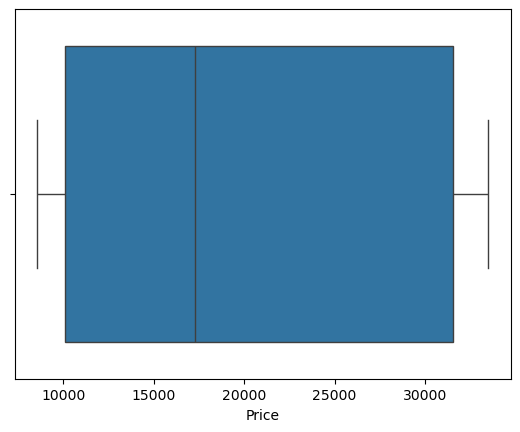

In [94]:
## checking the distribution of Price by BoxPlot
sns.boxplot(data=df,x="Price")

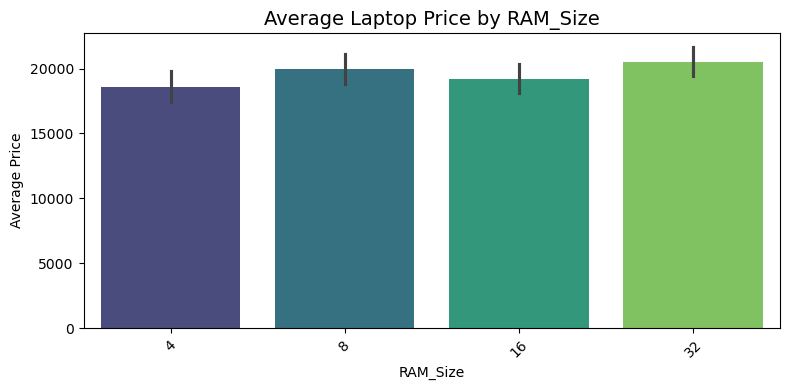

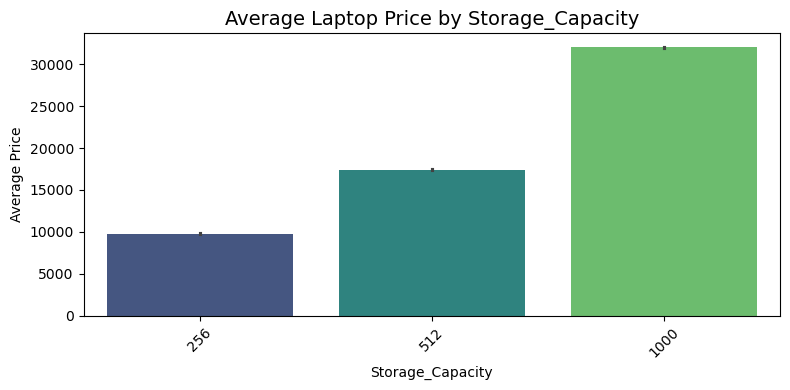

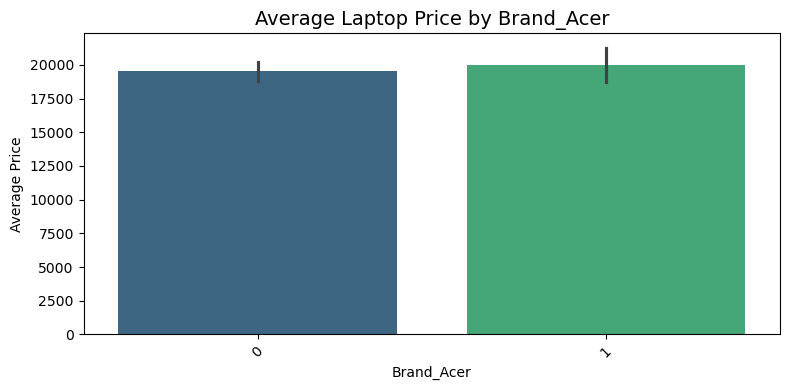

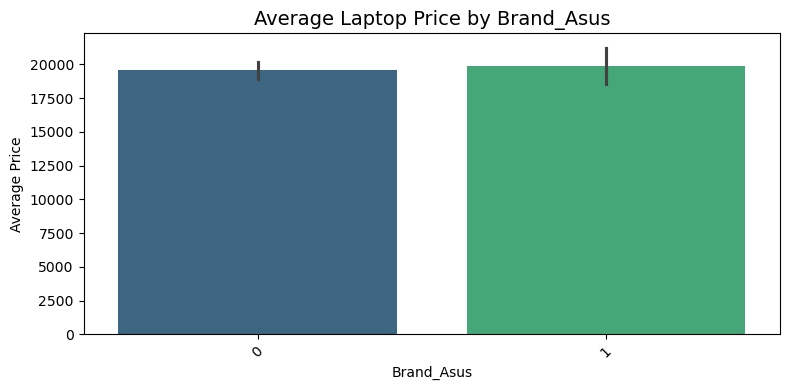

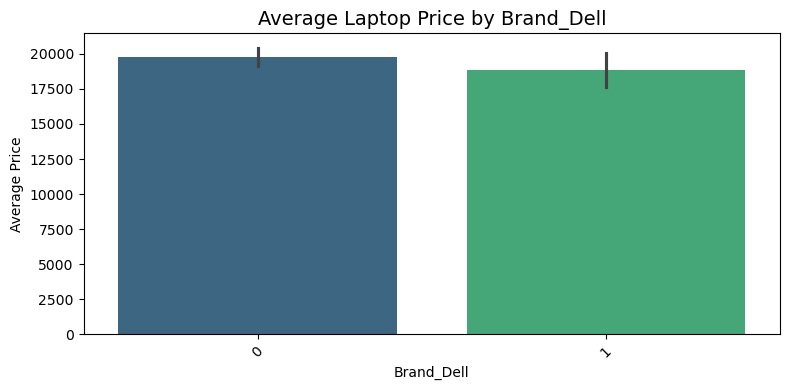

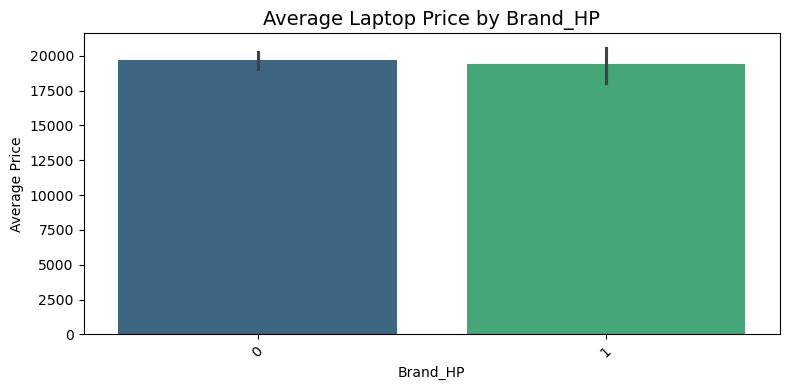

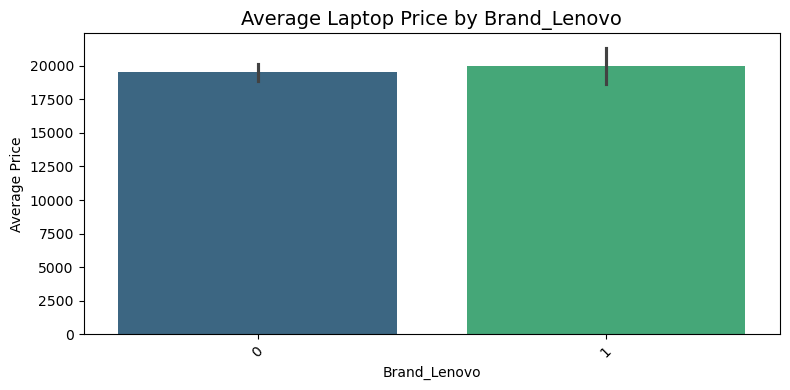

In [95]:
## Checking the relation between the Price & categorical columns by bar plot(Avg price)
for col in cat_columns:
    plt.figure(figsize=(8,4))
    sns.barplot(data=df, x=col, y='Price', estimator='mean', palette='viridis')
    plt.title(f'Average Laptop Price by {col}', fontsize=14)
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel('Average Price')
    plt.tight_layout()
    plt.show()

1. There is no much relation between Brand & Avg price.
2. There is a bit of relation observed betweem RAM_size & Avg price.
3. There is a significant relation observed between Storage_capacity & Avg Price

In [96]:
## Checking the relation between the Price & numerical columns by Scatter plot
num_columns = ["Processor_Speed",'Screen_Size','Weight']


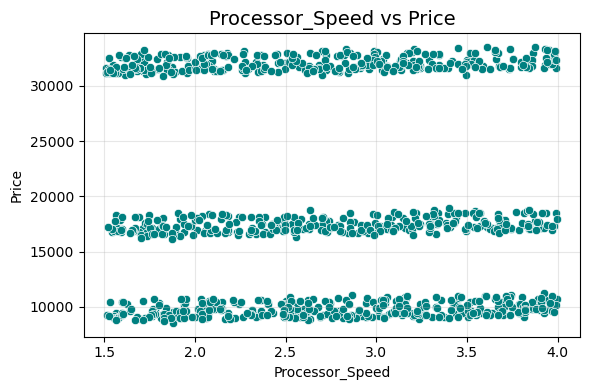

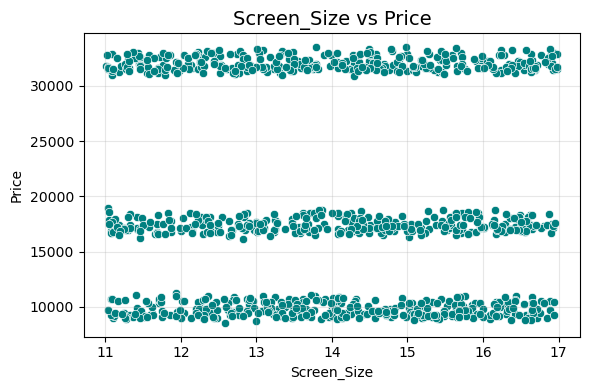

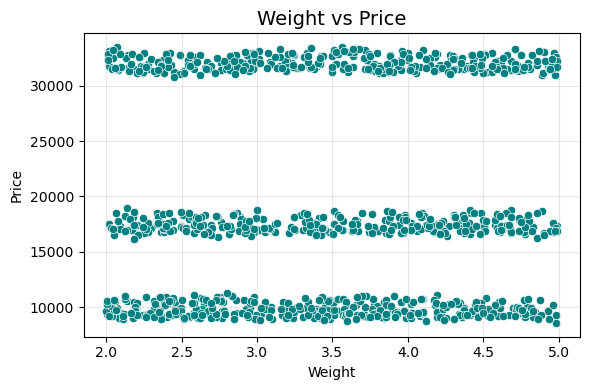

In [97]:
for col in num_columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y='Price', color='teal')
    plt.title(f'{col} vs Price', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

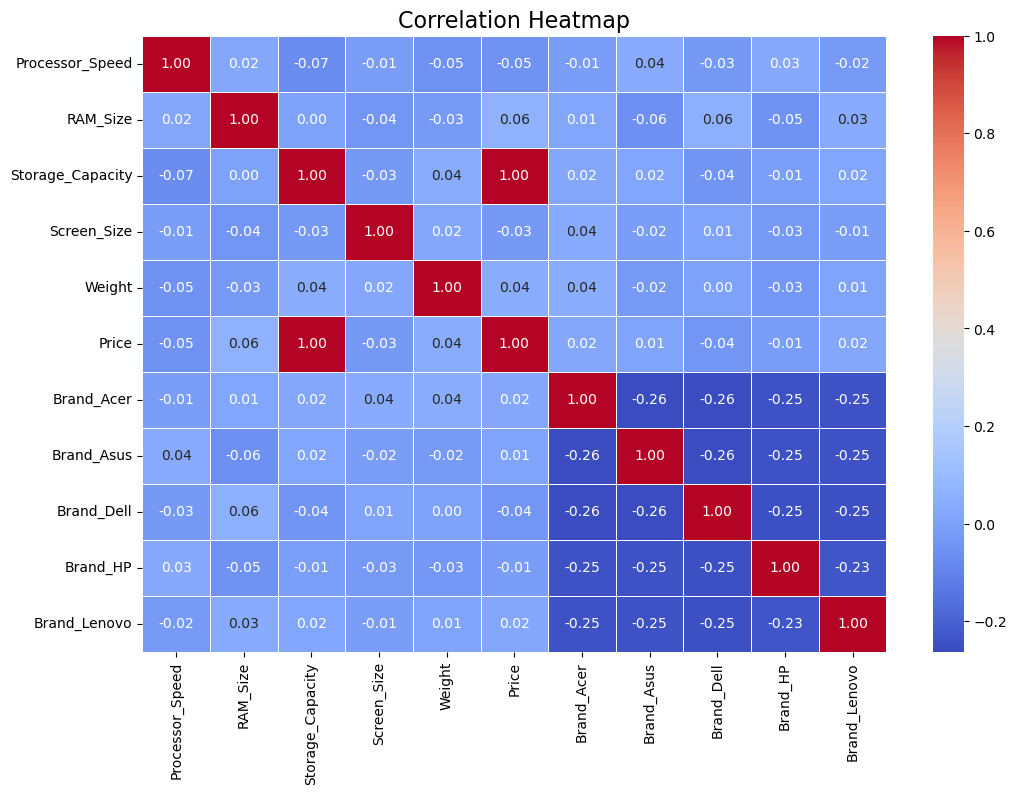

In [98]:
## Checking correllation of each column with Price
corr = df.corr(numeric_only=True)   # ensures it works even if non-numeric columns exist

plt.figure(figsize=(12, 8))         # ✅ use plt.figure, not plt.fig
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

| Feature              | Correlation with Price | Interpretation                                                        |
| -------------------- | ---------------------- | --------------------------------------------------------------------- |
| **Storage_Capacity** | **0.9979**             | Extremely high positive correlation — strongest predictor of Price.   |
| **RAM_Size**         | 0.0612                 | Weak positive correlation — may have a small effect.                  |
| **Weight**           | 0.0384                 | Very weak correlation — not meaningful for price prediction.          |
| **Processor_Speed**  | -0.0507                | Very weak negative correlation — little or no linear relationship.    |
| **Screen_Size**      | -0.0267                | Very weak negative correlation — negligible effect.                   |
| **Brand_***          | Around ±0.02           | All brand dummies have very weak correlation with Price individually. |

No strong multicollinearity among numeric predictors.

Dummy variables show expected negative correlations — that’s normal for one-hot encoding.

In [99]:
## we can drop Weight column as it does not have much impact on price
df = df.drop(columns=["Weight"])

In [100]:
df

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Price,Brand_Acer,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo
0,3.830296,16,512,11.185147,17395.093065,0,1,0,0,0
1,2.912833,4,1000,11.311372,31607.605919,1,0,0,0,0
2,3.241627,4,256,11.853023,9291.023542,0,0,0,0,1
3,3.806248,16,512,12.280360,17436.728334,1,0,0,0,0
4,3.268097,32,1000,14.990877,32917.990718,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
995,3.343584,4,1000,12.587095,31593.668017,0,0,0,1,0
996,2.780555,8,256,12.679356,9149.521832,0,0,1,0,0
997,3.200569,4,512,12.666315,16552.404779,0,0,1,0,0
998,1.604182,8,256,11.215581,9407.473459,0,1,0,0,0


In [101]:
## Splitting the data into X (Independent variables) & y (Dependent variable)
X = df.drop(columns=["Price"])
y = df["Price"]

In [102]:
from sklearn.preprocessing import StandardScaler

In [103]:
scaler = StandardScaler()

In [104]:
## Standardising the  Input data
X_scaled = scaler.fit_transform(X)

In [105]:
from sklearn.model_selection import train_test_split

In [106]:
## test train split
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.24,random_state=42)

In [107]:
from sklearn.linear_model import LinearRegression

In [108]:
model = LinearRegression()

In [109]:
## Model training
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [110]:
##Model testing
y_pred = model.predict(X_test)

In [111]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [112]:
MAE = mean_absolute_error(y_test,y_pred)
MSE = mean_squared_error(y_test,y_pred)
RMSE = np.sqrt(MSE)
r2 = r2_score(y_test, y_pred)
n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Mean absolute error:", MAE)
print("Mean Square error:", MSE)
print("Root Mean Square error:", RMSE)
print("R2 Score:", r2)
print("Adjusted R2 Score:", adjusted_r2)

Mean absolute error: 147.61280563362095
Mean Square error: 33137.47751891599
Root Mean Square error: 182.03702238532685
R2 Score: 0.9996261880714427
Adjusted R2 Score: 0.9996115606481513


By seeing R2 Score & Adjusted R2 Score we can say the model is working very well

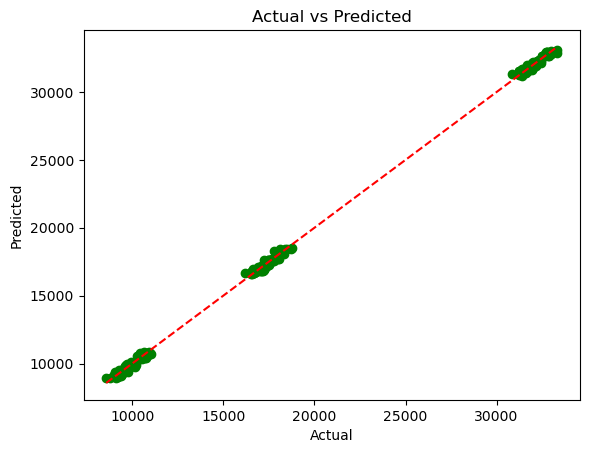

In [113]:
## Plotting the regression plot
plt.scatter(y_test, y_pred, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

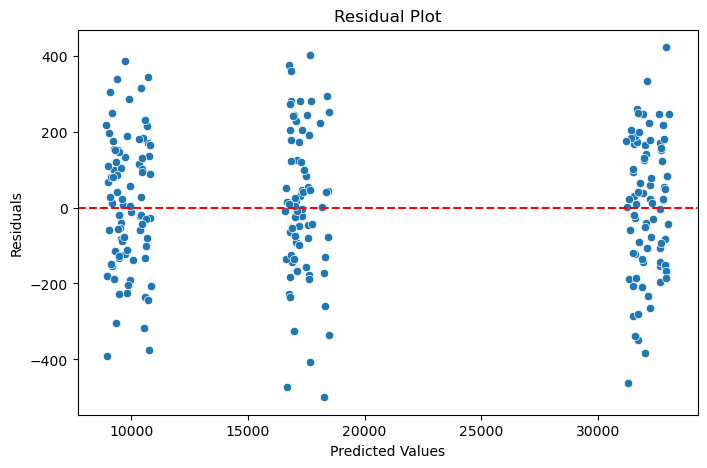

In [114]:
residuals = y_test - y_pred

# Residual plot
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

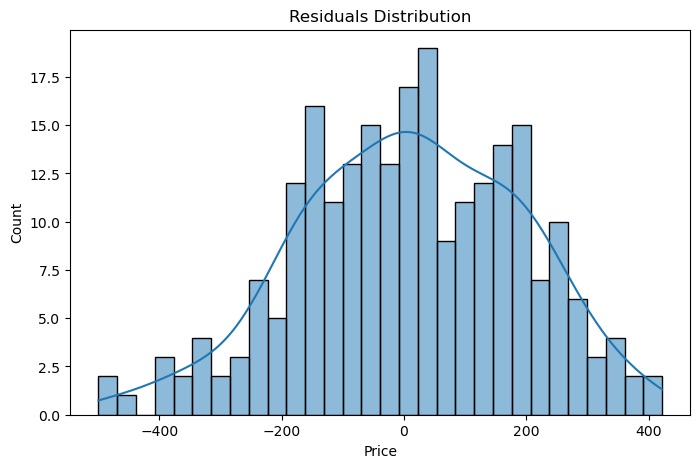

In [115]:
# Optional: distribution of residuals
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Residuals Distribution')
plt.show()

There is constant variance & Normal distribution of residuals

In [116]:
# Training performance
y_train_pred = model.predict(X_train)
print("Train R²:", r2_score(y_train, y_train_pred))
print("Train RMSE:", mean_squared_error(y_train, y_train_pred))

# Test performance
print("Test R²:", r2_score(y_test, y_pred))
print("Test RMSE:", mean_squared_error(y_test, y_pred))

Train R²: 0.9995469196736323
Train RMSE: 40002.87936508306
Test R²: 0.9996261880714427
Test RMSE: 33137.47751891599


Model is Performing well in both train & test data. So, there is no overfitting

In [117]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print("Cross-validation R² scores:", cv_scores)
print("Average CV R²:", cv_scores.mean())


Cross-validation R² scores: [0.99942531 0.99939885 0.99952029 0.999663   0.99957782]
Average CV R²: 0.9995170544188063


From Cross validation also it is proved that model is performing well

In [118]:
import pickle

In [119]:
# Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save scaler
with open('scalar.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model and scaler saved successfully as model.pkl and scalar.pkl")


✅ Model and scaler saved successfully as model.pkl and scalar.pkl


In [121]:
meta = {
    'expected_brand_cols': [col for col in X.columns if col.startswith('Brand_')],
    'numeric_cols': ['Processor_Speed', 'RAM_Size', 'Storage_Capacity', 'Screen_Size'],
    'feature_order': list(X.columns)
}

with open('meta.pkl', 'wb') as f:
    pickle.dump(meta, f)

print("✅ Metadata saved as meta.pkl")

✅ Metadata saved as meta.pkl
